In [1]:
import pandas as pd

In [2]:
firm_data = pd.read_excel('../data/processed/clean_firm_data.xlsx')

In [3]:
# filter from 2015
firm_data = firm_data[(firm_data['start_date'] >= '2015-01-01')]
print(firm_data['firm_name'].nunique())
print(firm_data['firm_name_preproc'].nunique())

11
11


In [4]:
panel = pd.read_parquet('../data/processed/panel_df.parquet')

In [ ]:
panel['nace_code'] = panel['nace_code'].astype(str).fillna('').str.zfill(4)

# initialize tech_level
panel['tech_level'] = 'Other'

# high-tech prefixes
high_tech = ['21', '26', '303']
panel.loc[panel['nace_code'].str.startswith(tuple(high_tech)), 'tech_level'] = 'high_tech'

# medium-high-tech prefixes
med_high_tech = ['20', '254', '27', '28', '29', '30', '325']
# exclude 301 and 303 from 30x
panel.loc[
    panel['nace_code'].str.startswith(tuple(med_high_tech)) &
    ~panel['nace_code'].str.startswith(('303')),
    'tech_level'
] = 'med_high_tech'

In [14]:
df_ht_mht = panel[panel['tech_level'].isin(['high_tech', 'med_high_tech'])]
df_ht_mht[df_ht_mht['treat'] == 1]['firm_id'].nunique()

44

In [19]:
pat_trend = df_ht_mht.groupby(['year', 'treat'])['ihs_pat_prio'].mean().reset_index()

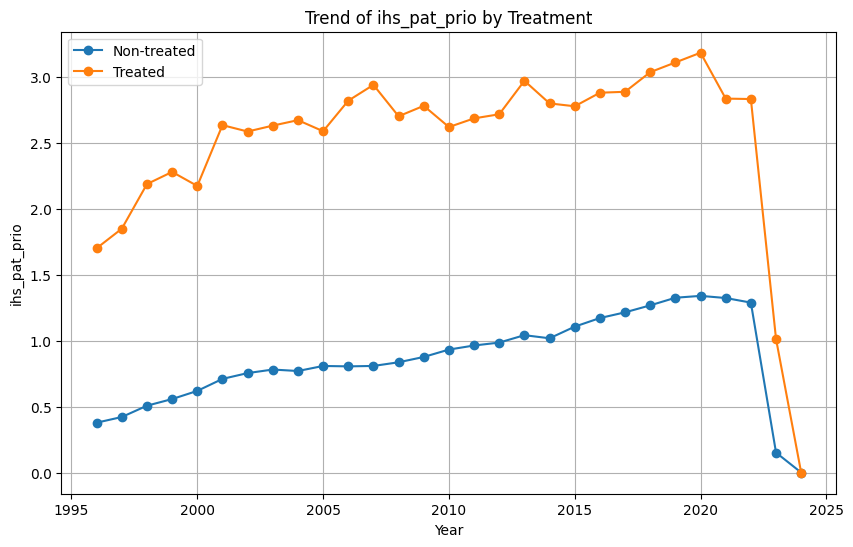

In [21]:
import matplotlib.pyplot as plt

treated = pat_trend[pat_trend['treat']==1]
non_treated = pat_trend[pat_trend['treat']==0]

plt.figure(figsize=(10,6))
plt.plot(non_treated['year'], non_treated['ihs_pat_prio'], marker='o', label='Non-treated')
plt.plot(treated['year'], treated['ihs_pat_prio'], marker='o', label='Treated')
plt.xlabel('Year')
plt.ylabel('ihs_pat_prio')
plt.title('Trend of ihs_pat_prio by Treatment')
plt.legend()
plt.grid(True)
plt.show()


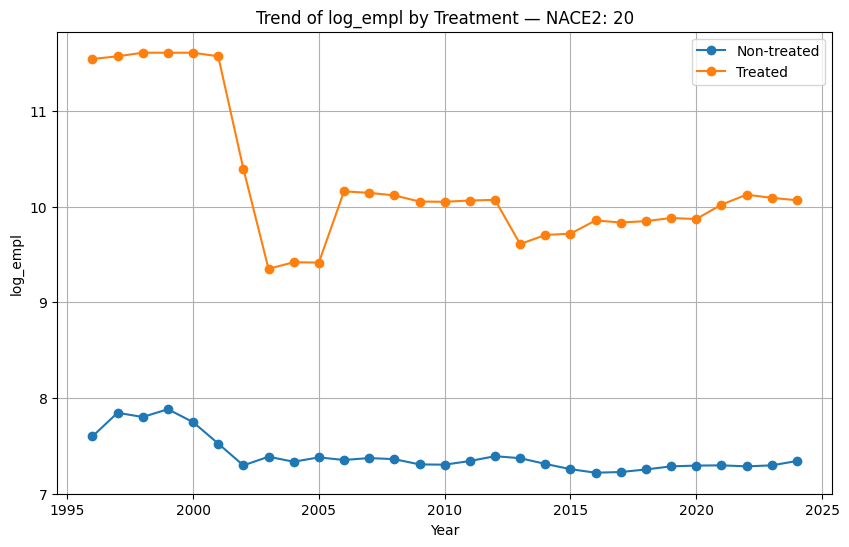

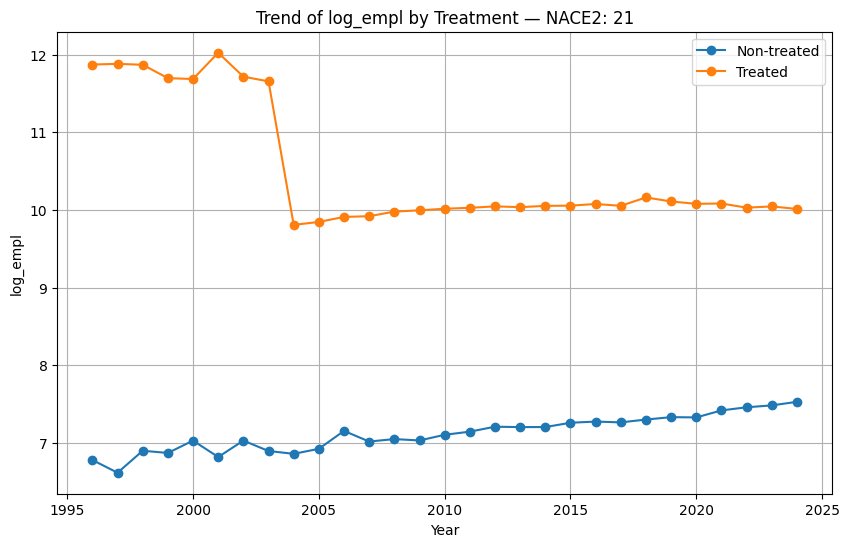

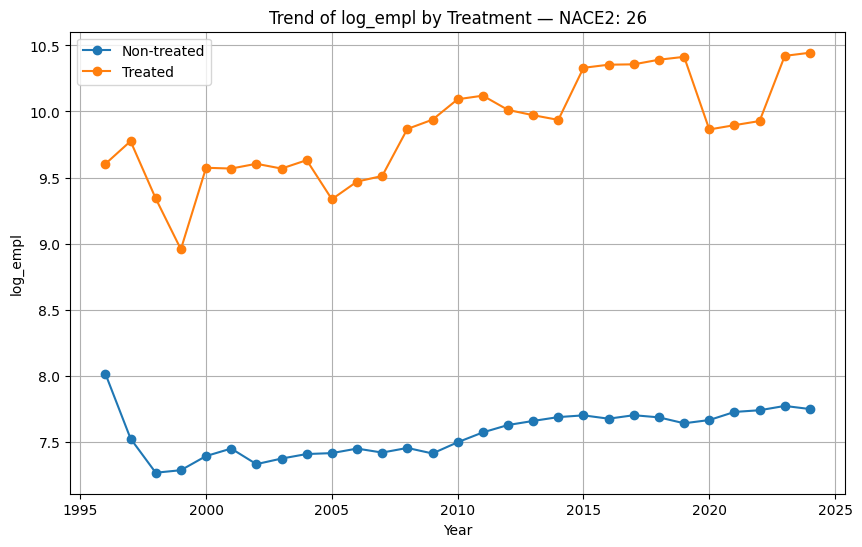

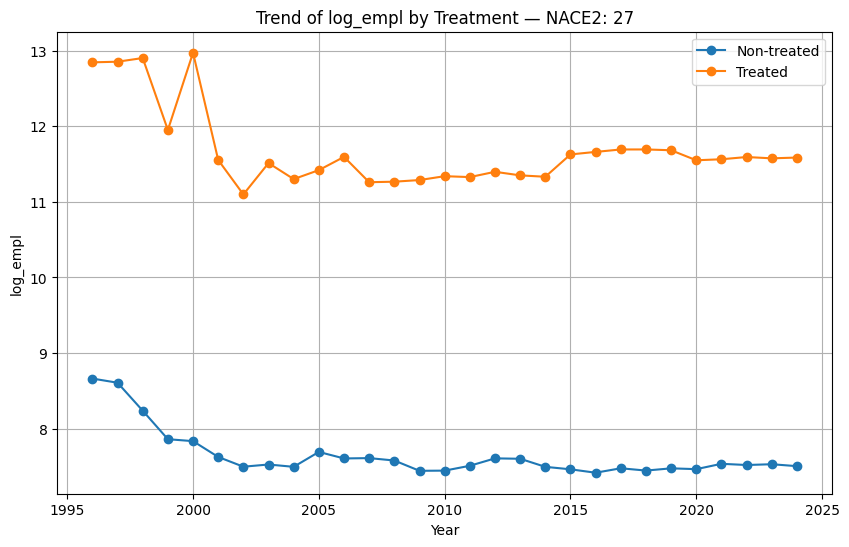

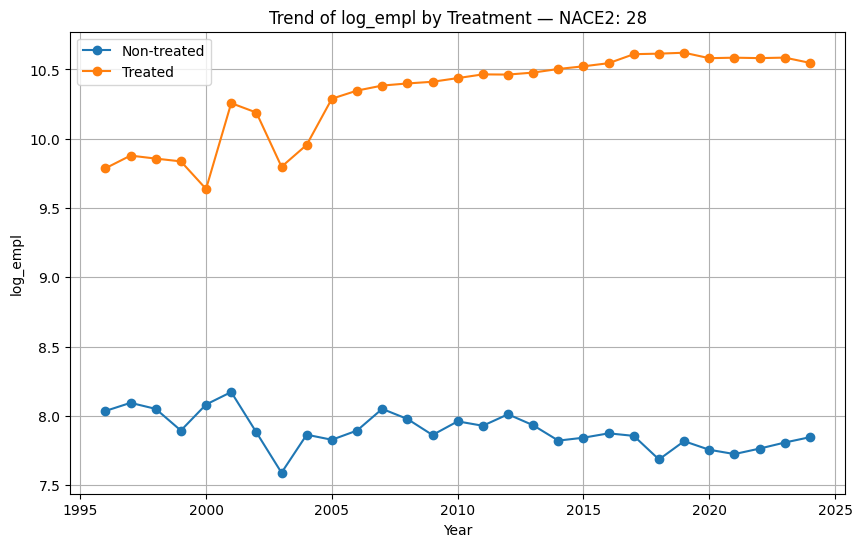

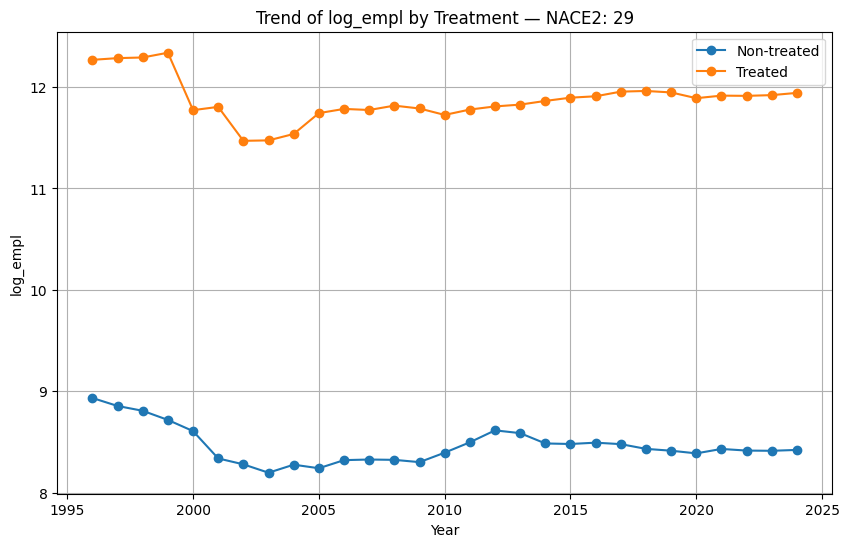

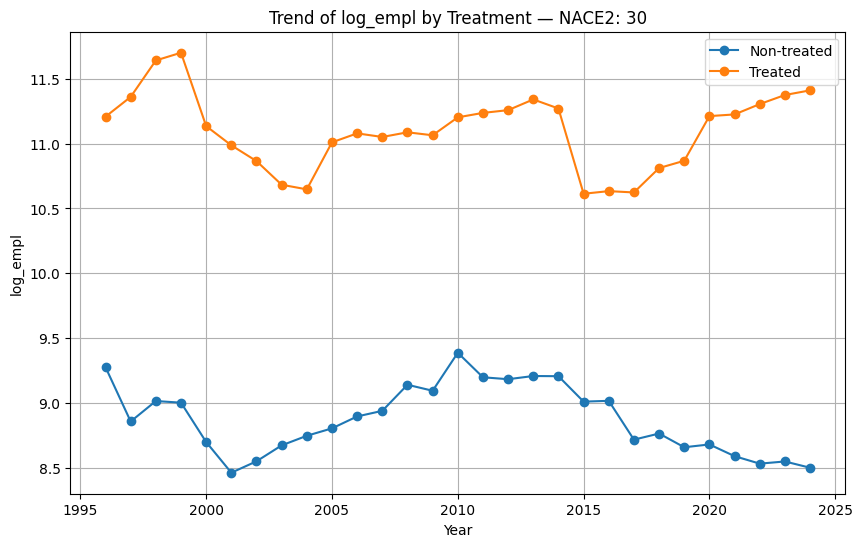

In [ ]:
log_empl_trend = df_ht_mht.groupby(['nace2', 'year', 'treat'])['log_empl'].mean().reset_index()

nace2_codes = log_empl_trend['nace2'].unique()

for code in nace2_codes:
    subset = log_empl_trend[log_empl_trend['nace2'] == code]
    
    treated = subset[subset['treat'] == 1]
    non_treated = subset[subset['treat'] == 0]
    
    plt.figure(figsize=(10,6))
    plt.plot(non_treated['year'], non_treated['log_empl'], marker='o', label='Non-treated')
    plt.plot(treated['year'], treated['log_empl'], marker='o', label='Treated')
    plt.xlabel('Year')
    plt.ylabel('log_empl')
    plt.title(f'Trend of log_empl by Treatment — NACE2: {code}')
    plt.legend()
    plt.grid(True)
    plt.show()


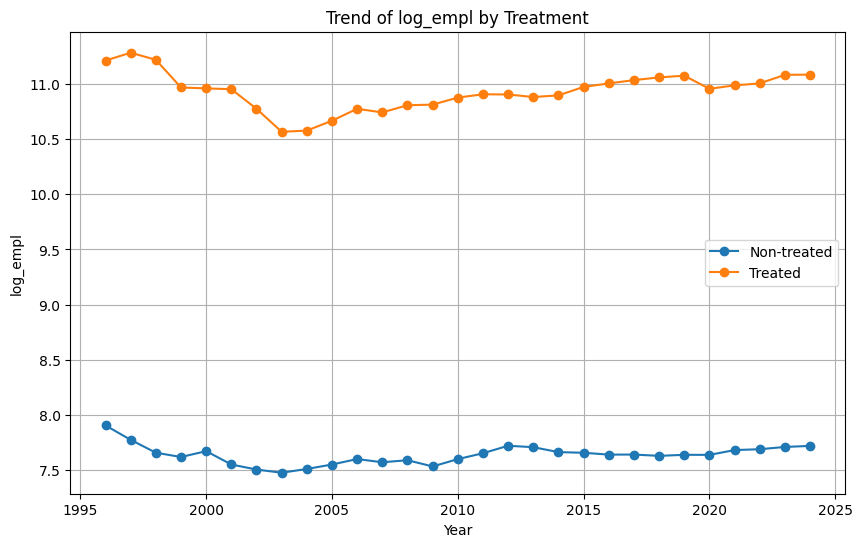

In [ ]:
log_empl_trend = df_ht_mht.groupby(['year', 'treat'])['log_empl'].mean().reset_index()

treated = log_empl_trend[log_empl_trend['treat']==1]
non_treated = log_empl_trend[log_empl_trend['treat']==0]

plt.figure(figsize=(10,6))
plt.plot(non_treated['year'], non_treated['log_empl'], marker='o', label='Non-treated')
plt.plot(treated['year'], treated['log_empl'], marker='o', label='Treated')
plt.xlabel('Year')
plt.ylabel('log_empl')
plt.title('Trend of log_empl by Treatment')
plt.legend()
plt.grid(True)
plt.show()



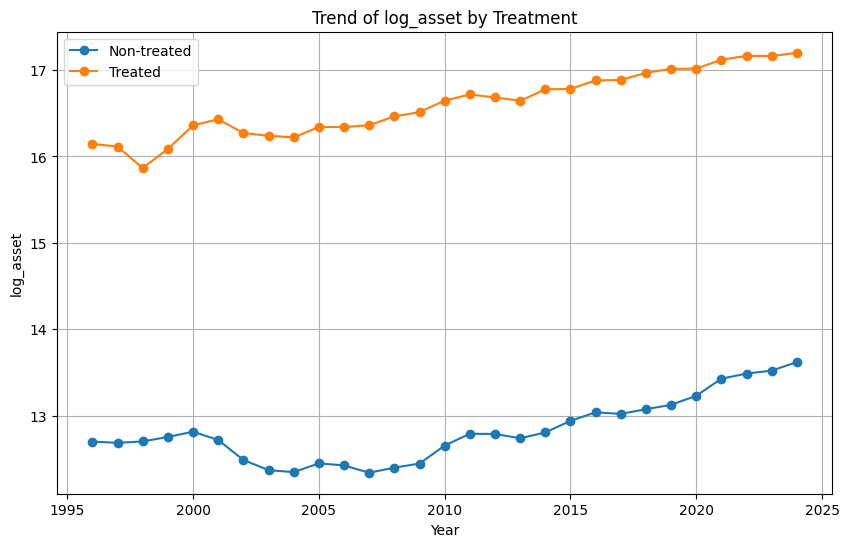

In [26]:
log_asset_trend = df_ht_mht.groupby(['year', 'treat'])['log_asset'].mean().reset_index()

treated = log_asset_trend[log_asset_trend['treat']==1]
non_treated = log_asset_trend[log_asset_trend['treat']==0]

plt.figure(figsize=(10,6))
plt.plot(non_treated['year'], non_treated['log_asset'], marker='o', label='Non-treated')
plt.plot(treated['year'], treated['log_asset'], marker='o', label='Treated')
plt.xlabel('Year')
plt.ylabel('log_asset')
plt.title('Trend of log_asset by Treatment')
plt.legend()
plt.grid(True)
plt.show()

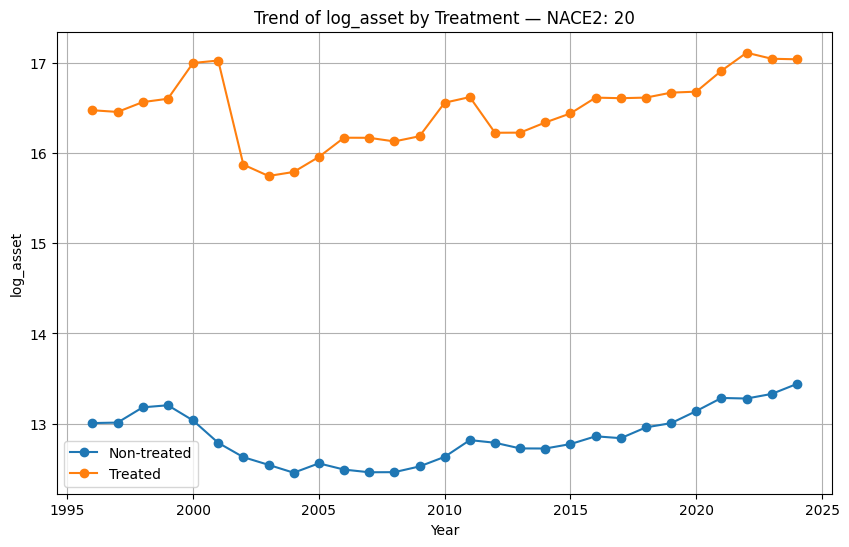

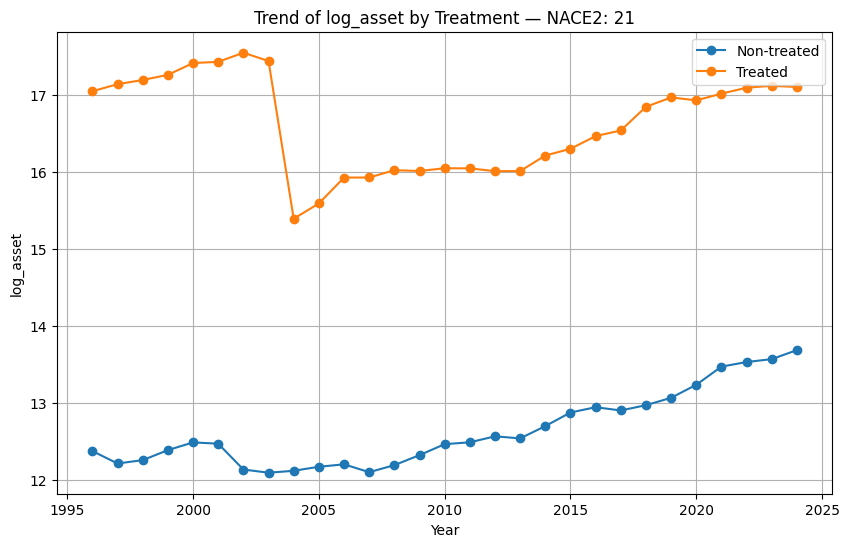

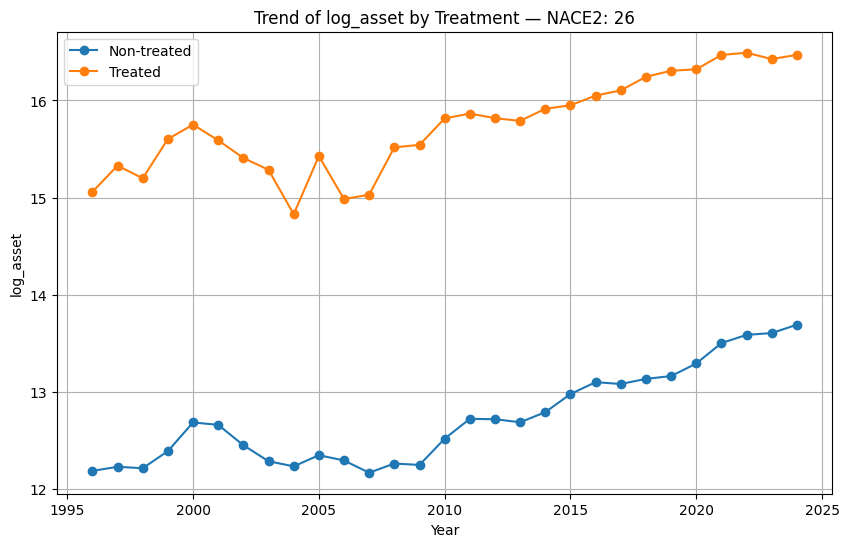

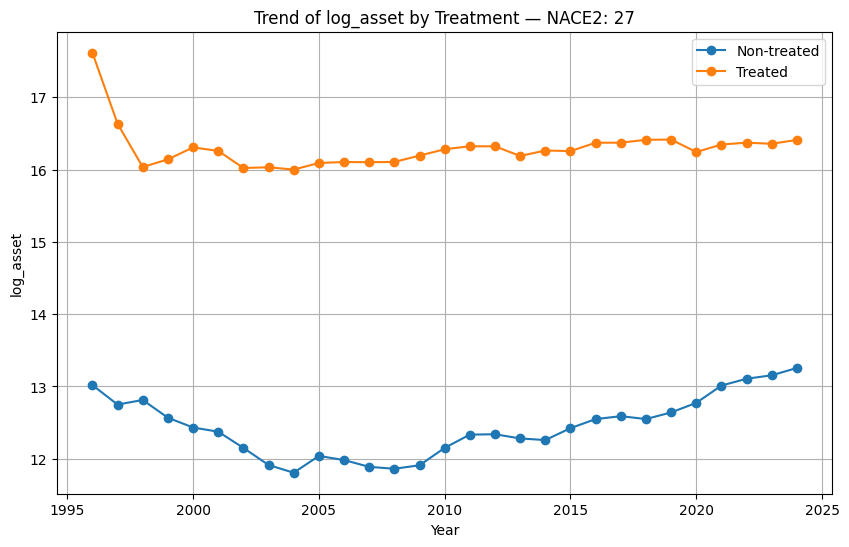

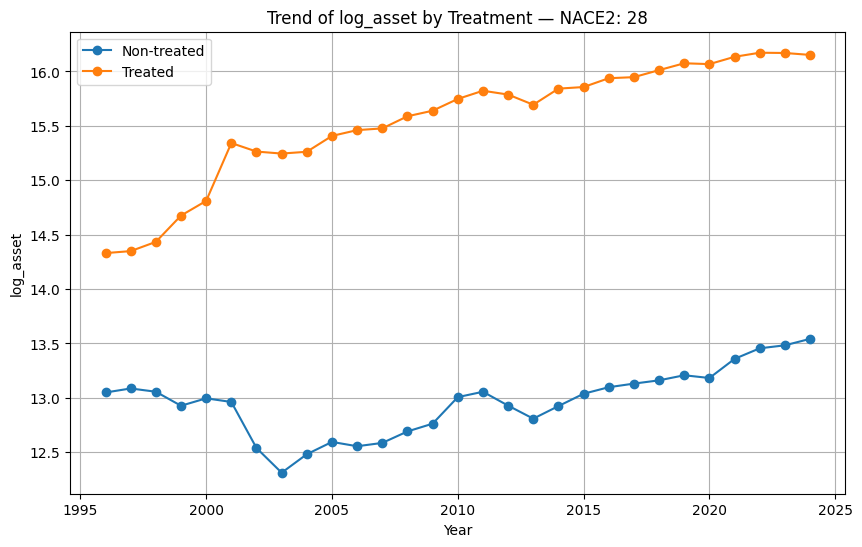

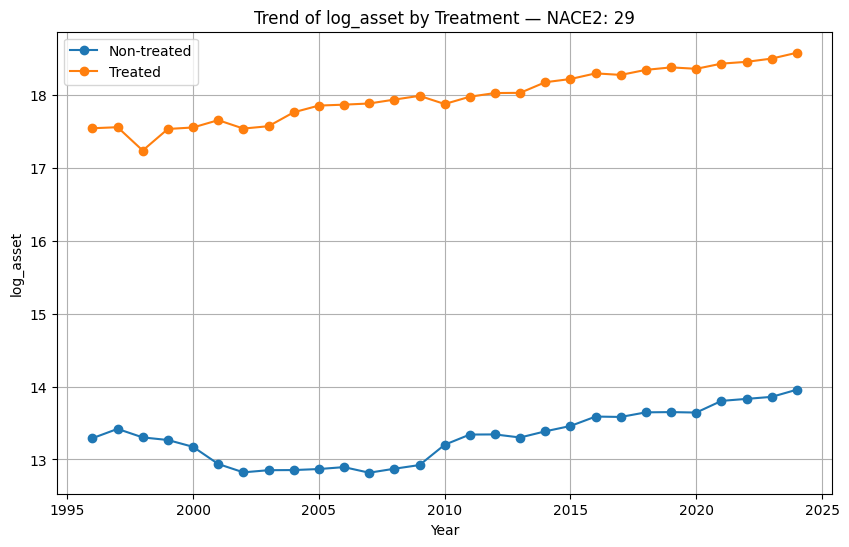

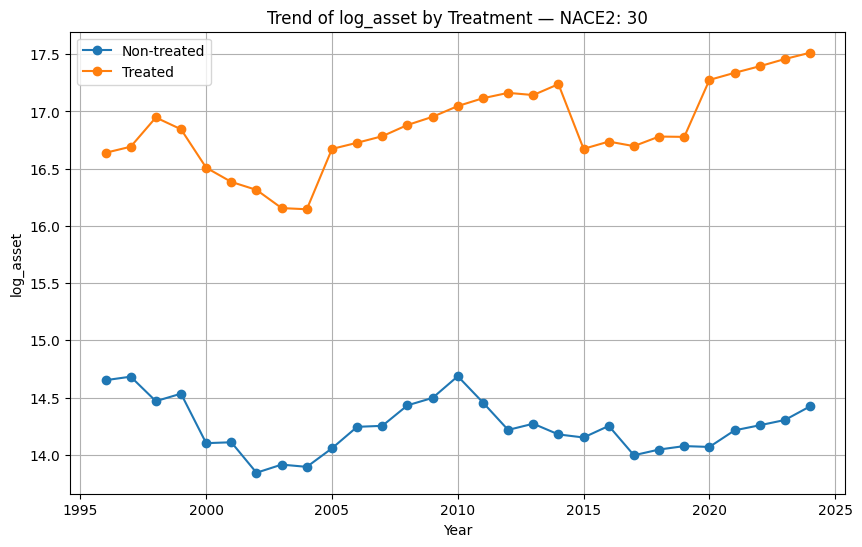

In [25]:
log_asset_trend = df_ht_mht.groupby(['nace2', 'year', 'treat'])['log_asset'].mean().reset_index()

nace2_codes = log_asset_trend['nace2'].unique()

for code in nace2_codes:
    subset = log_asset_trend[log_asset_trend['nace2'] == code]
    
    treated = subset[subset['treat'] == 1]
    non_treated = subset[subset['treat'] == 0]
    
    plt.figure(figsize=(10,6))
    plt.plot(non_treated['year'], non_treated['log_asset'], marker='o', label='Non-treated')
    plt.plot(treated['year'], treated['log_asset'], marker='o', label='Treated')
    plt.xlabel('Year')
    plt.ylabel('log_asset')
    plt.title(f'Trend of log_asset by Treatment — NACE2: {code}')
    plt.legend()
    plt.grid(True)
    plt.show()